In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
from PIL import Image
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pylab import *
import os
import sys

from keras.models import Model
from keras.regularizers import l2
from keras.layers import *

from keras.applications.vgg16 import *
from keras.models import *

import keras.backend as K
import tensorflow as tf
import torch
from tensorflow.keras import regularizers
from tensorflow.keras import Input
import keras
import keras.backend as K

C:\Users\James\anaconda3\envs\tf_2.6_py_3.7\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from tensorflow.keras.callbacks import LearningRateScheduler


In [3]:
path = 'C:\\Users\\James\\hwk03_data_new\\train\\pre'
os.chdir(path)
data = []
for i in range(1,301):
    img = Image.open('frame'+str(i)+'.bmp')
    img = np.array(img, dtype='f')
    img = img[61:567,10:550] # 將上方61個pixel 左方10個pixel 右方90個pixel切除  = (505,540)
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)  #resized 成 (224,224)
    img = img / 255  #歸一化
    data.append(img)

In [4]:
data = np.array(data)
data.shape

(300, 224, 224, 3)

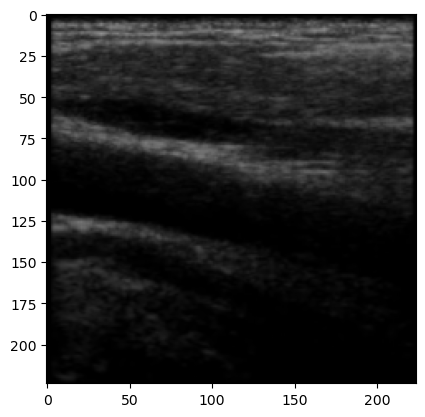

In [5]:
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(data[0])
plt.show()

In [6]:
path = 'C:\\Users\\James\\hwk03_data_new\\train\\post'
os.chdir(path)
label = []
for i in range(1,301):
    img = Image.open('frame'+str(i)+'.bmp_ROI.bmp')
    img = np.array(img, dtype='f')# 改為 0 ,1
    img = img[61:567,10:550]# 跟image 採一樣crop
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)#resized 成 (224,224)
    img[img > 0] = 1 #內插後，有些數值會跑掉。將大於0的pixel，通通 = 1
    img = np.expand_dims(img,axis=2)# channel = 1 才可augmentation，2無法。
    label.append(img)

In [7]:
label = np.array(label) # channel = 1 ，為了 augmentation ，augmentation做完轉回 channel = 2
label.shape

(300, 224, 224, 1)

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(data,label, test_size=0.20,random_state=666)
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)

(240, 224, 224, 3) (240, 224, 224, 1)
(60, 224, 224, 3) (60, 224, 224, 1)


In [9]:
from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical

class InputGenerator(Sequence):
    """Wrapper of 2 ImageDataGenerator"""

    def __init__(self, X1, X2, batch_size = 2):
         # Keras generator
        self.generator = ImageDataGenerator(rotation_range=20, 
                                            horizontal_flip=True,
                                            width_shift_range=0.1,
                                            height_shift_range=0.1,
                                            shear_range=1.25,
                                            zoom_range=0.1,
                                            fill_mode='nearest')

            # Real time multiple input data augmentation
        self.genX1 = self.generator.flow(X1, batch_size=batch_size, seed=1)
        self.genX2 = self.generator.flow(X2, batch_size=batch_size, seed=1)

    def __len__(self):
        """It is mandatory to implement it on Keras Sequence"""
        return self.genX1.__len__()

    def __getitem__(self, index):
        """Getting items from the 2 generators and packing them"""
        X1_batch = self.genX1.__getitem__(index)
        mask = self.genX2.__getitem__(index)


        y = to_categorical(mask, 2)

        return X1_batch, y

In [10]:
#valid不用做特別轉換，只是將之包起來
class validGenerator(Sequence):
    """Wrapper of 2 ImageDataGenerator"""

    def __init__(self, X1, X2, batch_size = 2):
        # Keras generator
        self.generator = ImageDataGenerator()
        # Real time multiple input data augmentation
        # Real time multiple input data augmentation
        self.genX1 = self.generator.flow(X1, batch_size=batch_size, seed=1)
        self.genX2 = self.generator.flow(X2, batch_size=batch_size, seed=1)
    def __len__(self):
        """It is mandatory to implement it on Keras Sequence"""
        return self.genX1.__len__()

    def __getitem__(self, index):
        """Getting items from the 2 generators and packing them"""
        X1_batch = self.genX1.__getitem__(index)
        mask = self.genX2.__getitem__(index)
        
        
        y = to_categorical(mask, 2)

        return X1_batch, y

In [11]:
train_batch = InputGenerator(X_train, y_train, batch_size = 2) 
val_batch = validGenerator(X_valid, y_valid, batch_size = 2) 

In [ ]:
#先做3*3 conv 兩次，接一個MAX pooling。
#重複上述動作 4次。(到U底部)

#接著再做2個3*3 conv，接一個upsampling，
#拿與之對應的conv4，做skip connection。
#重複上述動作，每個up 都拿對應的feature map 做skip connection。

#最後的skip connection 會接到 conv1，(None, 224, 224, 128)
#再做兩個3*3 conv。
#最後activation 用sigmoid ，得到最後output shape(None, 224, 224, 2) 


In [12]:
def unet():
    inputs = Input(shape=(224, 224, 3))
    conv1 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(inputs)
    conv1 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool1)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv4 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool3)
    conv4 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)
    conv5 = Conv2D(1024, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(pool4)
    conv5 = Conv2D(1024, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv5)
    
    up6 = Conv2D(512, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(
        UpSampling2D(size = (2,2))(conv5))
    merge6 = concatenate([conv4,up6], axis = 3)
    conv6 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge6)
    conv6 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv6)
    up7 = Conv2D(256, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(
        UpSampling2D(size = (2,2))(conv6))
    merge7 = concatenate([conv3,up7], axis = 3)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge7)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv7)
    up8 = Conv2D(128, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(
        UpSampling2D(size = (2,2))(conv7))
    merge8 = concatenate([conv2,up8], axis = 3)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge8)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv8)
    up9 = Conv2D(64, 2, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(
        UpSampling2D(size = (2,2))(conv8))
    merge9 = concatenate([conv1,up9], axis = 3)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(merge9)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = 'he_normal')(conv9)
    conv10 = Conv2D(2, 1, activation = 'sigmoid')(conv9)
    
    model = Model(inputs, conv10)
    
    
    return model

In [13]:
model = unet()

In [14]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 224, 224, 3) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 224, 224, 64) 1792        input_1[0][0]                    
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 224, 224, 64) 36928       conv2d[0][0]                     
__________________________________________________________________________________________________
max_pooling2d (MaxPooling2D)    (None, 112, 112, 64) 0           conv2d_1[0][0]                   
______________________________________________________________________________________________

In [16]:
from keras.callbacks import EarlyStopping

# early stop : 15個epoch val loss沒有減少，停止訓練
callback = EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=15,
    verbose=0,
    mode="min")

In [17]:
# lr scheduler 每過10個epoch，降低lr。lr從大至小，學習步伐越來越小，直至收斂。
def scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * tf.math.exp(-0.1)

In [18]:
callback2 = LearningRateScheduler(scheduler)

In [19]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=1e-4, decay=0.0) #優化採用adam ，

In [20]:
#loss 採binary crossentropy
model.compile(loss='binary_crossentropy',
              optimizer=optimizer,
              metrics=["accuracy",tf.keras.metrics.MeanIoU(num_classes=2)])
batch_size = 2
epochs = 100
show = X_train.shape[0]//batch_size
history = model.fit(train_batch, validation_data=val_batch,
                 steps_per_epoch= X_train.shape[0] // 2,
                validation_steps= X_valid.shape[0] // 2, 
                  epochs=epochs,verbose=2,
                    callbacks = [callback,callback2]
                  )

Epoch 1/100
120/120 - 31s - loss: 0.1950 - accuracy: 0.9275 - mean_io_u: 0.2858 - val_loss: 0.0701 - val_accuracy: 0.9754 - val_mean_io_u: 0.2595
Epoch 2/100
120/120 - 19s - loss: 0.0728 - accuracy: 0.9750 - mean_io_u: 0.3252 - val_loss: 0.0515 - val_accuracy: 0.9831 - val_mean_io_u: 0.2566
Epoch 3/100
120/120 - 19s - loss: 0.0638 - accuracy: 0.9770 - mean_io_u: 0.3723 - val_loss: 0.0382 - val_accuracy: 0.9845 - val_mean_io_u: 0.3997
Epoch 4/100
120/120 - 19s - loss: 0.0624 - accuracy: 0.9791 - mean_io_u: 0.4068 - val_loss: 0.0305 - val_accuracy: 0.9866 - val_mean_io_u: 0.5710
Epoch 5/100
120/120 - 19s - loss: 0.0449 - accuracy: 0.9835 - mean_io_u: 0.4702 - val_loss: 0.0320 - val_accuracy: 0.9865 - val_mean_io_u: 0.4971
Epoch 6/100
120/120 - 19s - loss: 0.0358 - accuracy: 0.9865 - mean_io_u: 0.5118 - val_loss: 0.0331 - val_accuracy: 0.9859 - val_mean_io_u: 0.5578
Epoch 7/100
120/120 - 19s - loss: 0.0332 - accuracy: 0.9872 - mean_io_u: 0.5289 - val_loss: 0.0298 - val_accuracy: 0.9873 - 

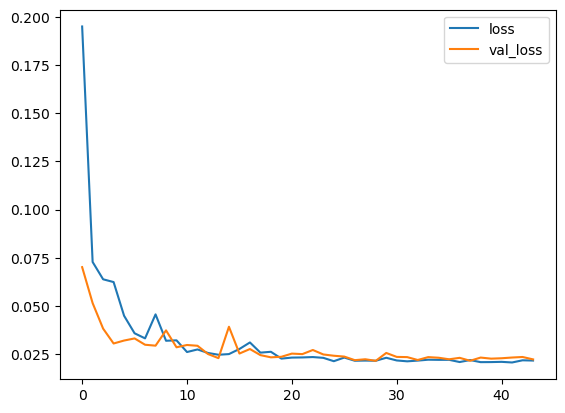

In [21]:
for key in ['loss', 'val_loss']:
    plt.plot(history.history[key],label=key)
plt.legend()
plt.show()

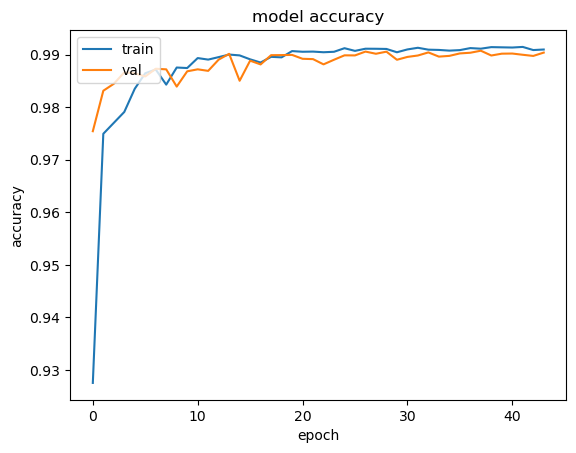

In [22]:
#plot history
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
    
    

In [ ]:
# val accuracy (pixel accuracy)最高達 0.9906  val_mean_iou 達0.823

In [23]:
path = 'C:\\Users\\James\\hwk03_data_new\\test\\pre'
os.chdir(path)
test = []
for i in range(301,401):
    img = Image.open('frame'+str(i)+'.bmp')
    img = np.array(img, dtype='f')
    img = img[61:567,10:550]
    img = cv2.resize(img, (224, 224), interpolation=cv2.INTER_AREA)
    img = img / 255  #歸一化
    test.append(img)

In [24]:
test=np.array(test)

In [25]:
test.shape

(100, 224, 224, 3)

In [26]:
y_pred = model.predict(test,batch_size=2)

In [27]:
y_pred.shape

(100, 224, 224, 2)

In [28]:
y_pred = np.argmax(y_pred, axis=3) # 改成one channel

In [29]:
y_pred.shape

(100, 224, 224)

In [30]:
from PIL import Image
for i in range(100):
    img = y_pred[i]
    img = np.array(img)
    img = img*255
    img = Image.fromarray(img.astype(np.uint8))
    img.save('C:\\Users\\James\\unet6\\'+str(i)+'.jpg')


In [31]:
for i in range(100):
    img = y_pred[i]
    img = np.array(img,dtype='uint8')
    img = cv2.resize(img, (540, 505), interpolation=cv2.INTER_AREA)# 先resize回(505,540)。cv2 和 np 長寬相反要注意
    img = np.pad(img,((61,0),(10,90)),'constant', constant_values=0)#根據先前crop補回0，上方補61 左方補10 右方補90
    img = np.array(img,dtype='bool')# 改為booling
    img = Image.fromarray(img)
    img.save('C:\\Users\\James\\unet_post\\frame'+str(301+i)+'.bmp_ROI.bmp','bmp')#輸出結果